In [1]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime

fission = "http://localhost:9090"

In [2]:
def format_date(date):
    return date.strftime("%Y-%m-%d")

def dataframe(data, start):
    base = datetime.datetime.today()
    num_days = (base - datetime.datetime.fromisoformat(start)).days
    date_list = [format_date(base - datetime.timedelta(days=x)) for x in range(num_days, -1, -1)]
    df = pd.DataFrame.from_dict(data, orient="index").reindex(date_list)
    return df

In [3]:
start_date = "2025-05-01"
response = requests.get(
        url=f"{fission}/ui/sentiment/start/{start_date}/",
        timeout=600
    )

print(response)
keys = ["bluesky", "reddit", "openaus"]
data = response.json()
df = {}
for s in keys:
    df[s] = dataframe(data[s], start_date)

<Response [200]>


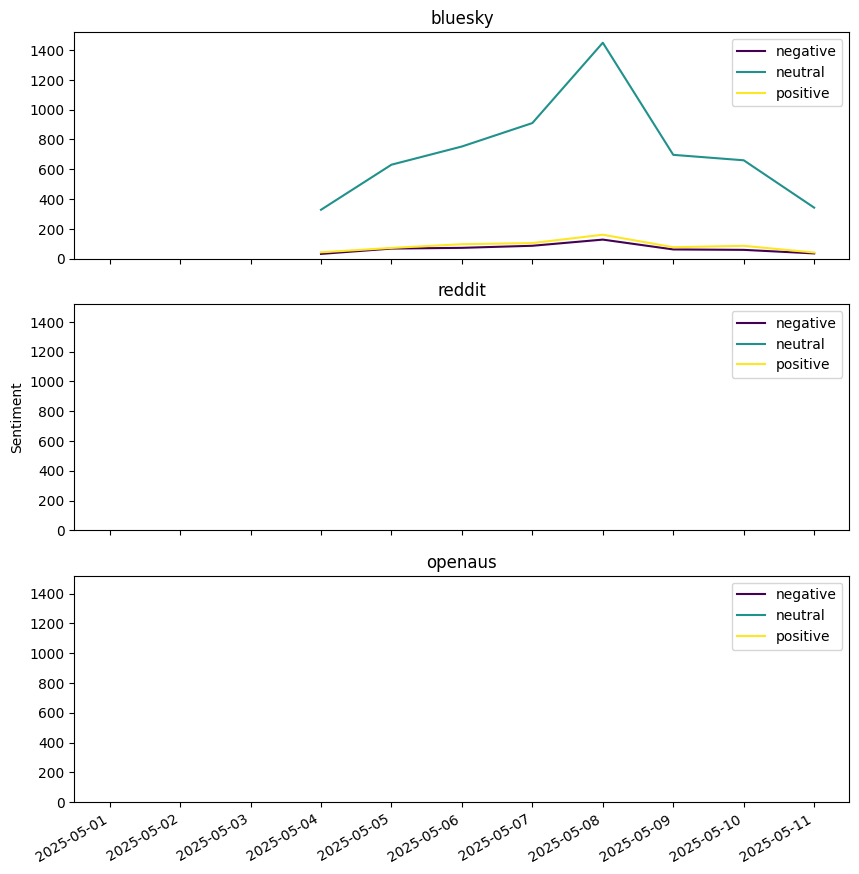

In [4]:
# colors
cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0, 1, 3))

# plot
fig, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(10, 10))
ax[int(len(keys) / 2)].set_ylabel("Sentiment", loc="center")

for i, s in enumerate(keys):
    temp_df = df[s]
    
    ax[i].plot(temp_df['neg'], label="negative", color=colors[0])
    ax[i].plot(temp_df['neu'], label="neutral", color=colors[1])
    ax[i].plot(temp_df['pos'], label="positive", color=colors[2])
    
    plt.xticks(rotation=30, ha='right');
    ax[i].legend(loc="upper right")
    ax[i].set_title(s)
    ax[i].set_ylim(bottom=0)

plt.show()